<a href="https://colab.research.google.com/github/khouloud-ghabi/Data_Cleaning/blob/main/Churn_Task1_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Cleaning

In [18]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('All libraries imported')

All libraries imported



 Load the Dataset

In [19]:
# Load both files
df_train = pd.read_csv('churn-bigml-80.csv')
df_test  = pd.read_csv('churn-bigml-20.csv')

# Tag each row so we can split again after cleaning
df_train['_split'] = 'train'
df_test['_split']  = 'test'

# Merge into one DataFrame
df = pd.concat([df_train, df_test], ignore_index=True)

print(f'Training rows  : {len(df_train):,}')
print(f'Test rows      : {len(df_test):,}')
print(f'Combined rows  : {len(df):,}')
print(f'Columns        : {df.shape[1]}')

Training rows  : 2,666
Test rows      : 667
Combined rows  : 3,333
Columns        : 21


In [20]:
# First look at the data
df.head(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,_split
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False,train
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False,train
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False,train
3,OH,84,408,Yes,No,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,False,train
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False,train
5,AL,118,510,Yes,No,0,223.40,98,37.98,220.60,101,18.75,203.90,118,9.18,6.30,6,1.70,0,False,train
6,MA,121,510,No,Yes,24,218.20,88,37.09,348.50,108,29.62,212.60,118,9.57,7.50,7,2.03,3,False,train
7,MO,147,415,Yes,No,0,157.00,79,26.69,103.10,94,8.76,211.80,96,9.53,7.10,6,1.92,0,False,train
8,WV,141,415,Yes,Yes,37,258.60,84,43.96,222.00,111,18.87,326.40,97,14.69,11.20,5,3.02,0,False,train
9,RI,74,415,No,No,0,187.70,127,31.91,163.40,148,13.89,196.00,94,8.82,9.10,5,2.46,0,False,train


In [21]:
# ── Last rows ─────────────────────────────────────────────────────
df.tail(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,_split
3328,WI,114,415,No,Yes,26,137.10,88,23.31,155.70,125,13.23,247.60,94,11.14,11.50,7,3.11,2,False,test
3329,AL,106,408,No,Yes,29,83.60,131,14.21,203.90,131,17.33,229.50,73,10.33,8.10,3,2.19,1,False,test
3330,VT,60,415,No,No,0,193.90,118,32.96,85.00,110,7.23,210.10,134,9.45,13.20,8,3.56,3,False,test
3331,WV,159,415,No,No,0,169.80,114,28.87,197.70,105,16.80,193.70,82,8.72,11.60,4,3.13,1,False,test
3332,CT,184,510,Yes,No,0,213.80,105,36.35,159.60,84,13.57,139.20,137,6.26,5.00,10,1.35,2,False,test


---
## 3. Initial Exploration <a id='3'></a>

Before cleaning, we perform a **systematic audit** of the raw data to understand its structure, data types, and any immediate red flags.

In [22]:
# Shape and column overview
print('='*60)
print(f'  DATASET SHAPE: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print('='*60)
print()
print(df.info())

  DATASET SHAPE: 3,333 rows  ×  21 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 

In [23]:
# Statistical summary  numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','max'])

,count,mean,std,min,25%,50%,75%,max
Account length,3333.000000,101.064806,39.822106,1.000000,74.000000,101.000000,127.000000,243.000000
Area code,3333.000000,437.182418,42.371290,408.000000,408.000000,415.000000,510.000000,510.000000
Number vmail messages,3333.000000,8.099010,13.688365,0.000000,0.000000,0.000000,20.000000,51.000000
Total day minutes,3333.000000,179.775098,54.467389,0.000000,143.700000,179.400000,216.400000,350.800000
Total day calls,3333.000000,100.435644,20.069084,0.000000,87.000000,101.000000,114.000000,165.000000
Total day charge,3333.000000,30.562307,9.259435,0.000000,24.430000,30.500000,36.790000,59.640000
Total eve minutes,3333.000000,200.980348,50.713844,0.000000,166.600000,201.400000,235.300000,363.700000
Total eve calls,3333.000000,100.114311,19.922625,0.000000,87.000000,100.000000,114.000000,170.000000
Total eve charge,3333.000000,17.083540,4.310668,0.000000,14.160000,17.120000,20.000000,30.910000
Total night minutes,3333.000000,200.872037,50.573847,23.200000,167.000000,201.200000,235.300000,395.000000


In [24]:
# Statistical summary categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
df[cat_cols].describe()

Categorical columns: ['State', 'International plan', 'Voice mail plan', '_split']


,State,International plan,Voice mail plan,_split
count,3333,3333,3333,3333
unique,51,2,2,2
top,WV,No,No,train
freq,106,3010,2411,2666


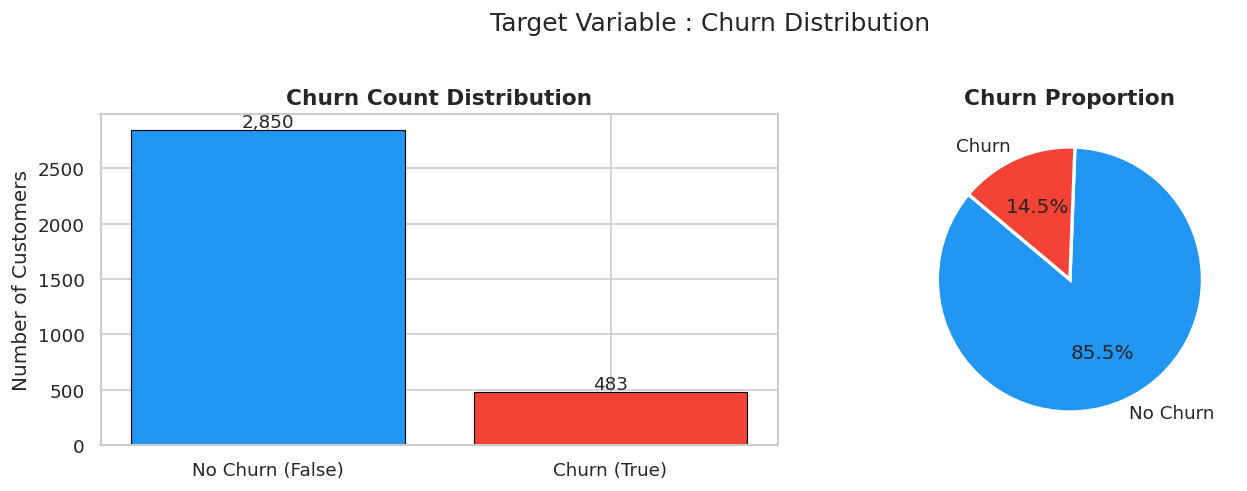


Churn rate: 14.5%  |  Retention rate: 85.5%


In [25]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Churn (False)', 'Churn (True)'],
            churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Churn Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(churn_pct.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3','#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable : Churn Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', bbox_inches='tight')
plt.show()
print(f'\nChurn rate: {churn_pct[True]:.1f}%  |  Retention rate: {churn_pct[False]:.1f}%')


Missing Values  Detection and Handling

1. Detect all missing values and compute their percentage
2. Visualise the missingness pattern
3. Apply the appropriate strategy per column:
   - Numeric → median imputation (robust to outliers)
   - Categorical → mode imputation
   - Drop if > 50% missing (none expected here)

In [26]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'Missing Count'   : df.isnull().sum(),
    'Missing %'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type'       : df.dtypes
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('\n Columns with Missing Values:')
print('='*50)
print(missing.to_string())
print(f'\nTotal missing cells : {df.isnull().sum().sum():,}')
print(f'Overall missing %   : {df.isnull().sum().sum() / df.size * 100:.2f}%')


 Columns with Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %, Data Type]
Index: []

Total missing cells : 0
Overall missing %   : 0.00%


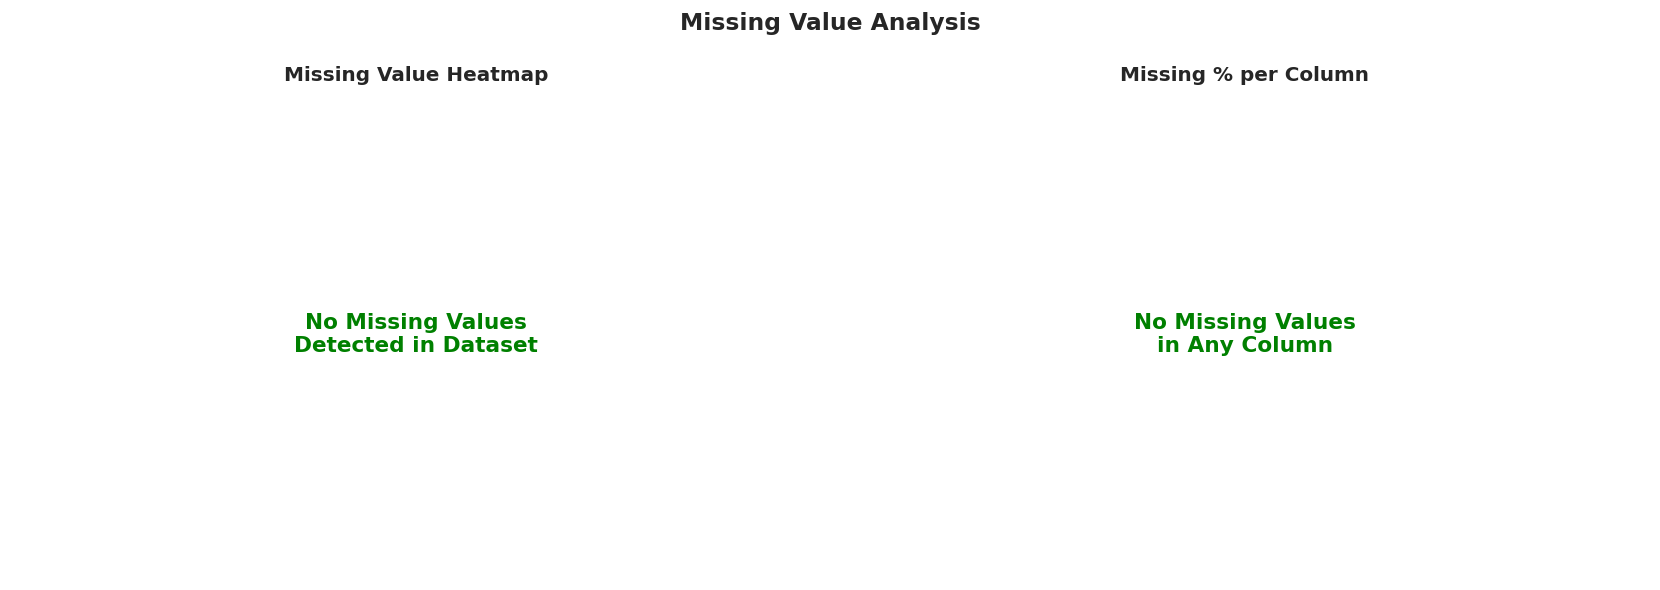

 Missing value analysis complete  no nulls found in this dataset


In [27]:
#  Visualise missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of nulls  guard against no-NA case
cols_with_na = df.columns[df.isnull().any()].tolist()
if cols_with_na:
    sns.heatmap(df[cols_with_na].isnull(),
                yticklabels=False, cbar=False,
                cmap='viridis', ax=axes[0])
    axes[0].set_title('Missing Value Heatmap\n(yellow = missing)', fontsize=12, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values\nDetected in Dataset',
                 ha='center', va='center', fontsize=13, fontweight='bold',
                 color='green', transform=axes[0].transAxes)
    axes[0].set_title('Missing Value Heatmap', fontsize=12, fontweight='bold')
    axes[0].axis('off')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Bar chart of missing %
if not missing.empty:
    axes[1].barh(missing.index, missing['Missing %'],
                 color='#FF7043', edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('Missing Percentage (%)')
    axes[1].set_title('Missing % per Column', fontsize=12, fontweight='bold')
    for i, v in enumerate(missing['Missing %']):
        axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)
    axes[1].axvline(x=5, color='red', linestyle='-', linewidth=1, label='5% threshold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No Missing Values\nin Any Column',
                 ha='center', va='center', fontsize=13, fontweight='bold',
                 color='green', transform=axes[1].transAxes)
    axes[1].set_title('Missing % per Column', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_missing_values.png', bbox_inches='tight')
plt.show()
print(' Missing value analysis complete  no nulls found in this dataset')


In [28]:
# Imputation Strategy
print('pplying Imputation Strategy')
print('-'*50)

imputation_log = []

for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing == 0:
        continue

    pct = n_missing / len(df) * 100

    # Decision: drop column if > 50% missing (none expected)
    if pct > 50:
        df.drop(columns=[col], inplace=True)
        strategy = f'DROPPED (>{pct:.1f}% missing)'

    # Numeric → median imputation
    elif df[col].dtype in ['float64', 'int64']:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        strategy = f'Median imputation  →  filled with {fill_val:.2f}'

    # Categorical → mode imputation
    else:
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        strategy = f'Mode imputation    →  filled with "{fill_val}"'

    imputation_log.append({'Column': col, 'Missing (before)': n_missing,
                           'Missing %': f'{pct:.2f}%', 'Strategy': strategy})

imp_df = pd.DataFrame(imputation_log)

if imp_df.empty:
    print(' No missing values found ')
else:
    print(imp_df.to_string(index=False))

# Verify
remaining_na = df.isnull().sum().sum()
print(f'\n Missing values remaining after imputation: {remaining_na}')


pplying Imputation Strategy
--------------------------------------------------
 No missing values found 

 Missing values remaining after imputation: 0


---
## 5. Duplicate Rows — Detection & Removal <a id='5'></a>

Duplicate rows inflate dataset size and can cause a model to **overfit** to specific observations. We detect and remove them.

In [29]:
# Detect duplicates
n_before = len(df)
n_dupes  = df.duplicated().sum()

print('='*50)
print(f'  Total rows (before dedup) : {n_before:,}')
print(f'  Duplicate rows found      : {n_dupes:,}')
print(f'  Duplication rate          : {n_dupes/n_before*100:.2f}%')
print('='*50)

# Preview duplicate rows
if n_dupes > 0:
    print(f'\n First 5 duplicate rows (preview):')
    print(df[df.duplicated(keep=False)].head(10).to_string())

  Total rows (before dedup) : 3,333
  Duplicate rows found      : 0
  Duplication rate          : 0.00%


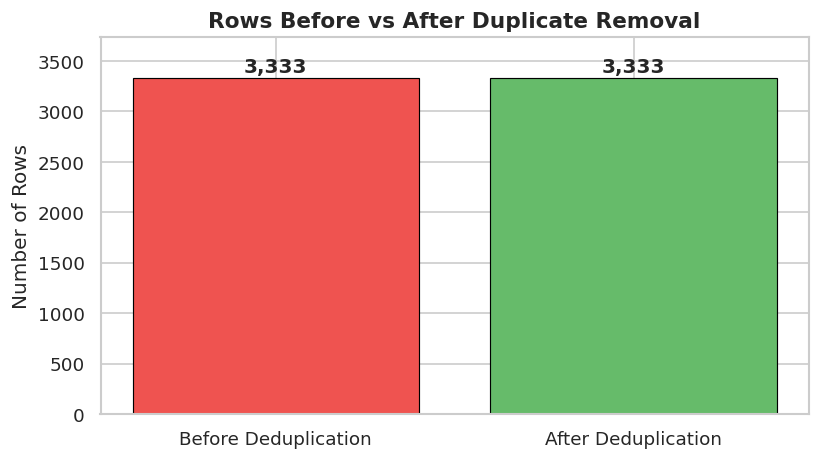

Removed 0 duplicate rows
   Rows remaining: 3,333


In [30]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)

# Visual summary
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Before Deduplication', 'After Deduplication'],
               [n_before, n_after],
               color=['#EF5350', '#66BB6A'], edgecolor='black', linewidth=0.7)
ax.set_ylabel('Number of Rows')
ax.set_title('Rows Before vs After Duplicate Removal', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [n_before, n_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(n_before, n_after) * 1.12)
plt.tight_layout()
plt.savefig('03_deduplication.png', bbox_inches='tight')
plt.show()

print(f'Removed {n_before - n_after:,} duplicate rows')
print(f'   Rows remaining: {n_after:,}')


## Inconsistent Data Formats  Standardization

1. Audit all categorical columns
2. Standardize to a consistent format (Title Case)
3. Map boolean-like columns to proper `True/False`

In [31]:
# Audit categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Remove helper columns from audit
audit_cols = [c for c in cat_cols if c not in ['_split']]

print('Unique Values in Categorical Columns:')
print('='*60)
for col in audit_cols:
    uniques = df[col].unique()
    print(f'\n  [{col}]  ({len(uniques)} unique values)')
    print(f'  → {sorted([str(u) for u in uniques])}')

Unique Values in Categorical Columns:

  [State]  (51 unique values)
  → ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

  [International plan]  (2 unique values)
  → ['No', 'Yes']

  [Voice mail plan]  (2 unique values)
  → ['No', 'Yes']


In [32]:
# Standardize string columns
print('Standardizing categorical columns...')
print('─'*50)

binary_map = {'yes': 'Yes', 'YES': 'Yes', 'no': 'No', 'NO': 'No'}

for col in audit_cols:
    before = df[col].unique().tolist()

    # Strip whitespace
    df[col] = df[col].astype(str).str.strip()

    # Title-case for Yes/No binary columns
    if set(df[col].str.lower().unique()) <= {'yes', 'no', 'nan'}:
        df[col] = df[col].str.strip().replace(binary_map)

    # State codes — upper case
    elif col == 'State':
        df[col] = df[col].str.upper()

    after = df[col].unique().tolist()
    if sorted([str(b) for b in before]) != sorted([str(a) for a in after]):
        print(f'  [{col}]')
        print(f'    Before → {sorted([str(b) for b in before])}')
        print(f'    After  → {sorted([str(a) for a in after])}')

print('\n Categorical columns standardized!')

Standardizing categorical columns...
──────────────────────────────────────────────────

 Categorical columns standardized!


In [33]:
# Validate after standardization
print('Post-standardization value counts:')
for col in ['International plan', 'Voice mail plan']:
    print(f'\n  [{col}]')
    print(df[col].value_counts().to_string())

Post-standardization value counts:

  [International plan]
International plan
No     3010
Yes     323

  [Voice mail plan]
Voice mail plan
No     2411
Yes     922


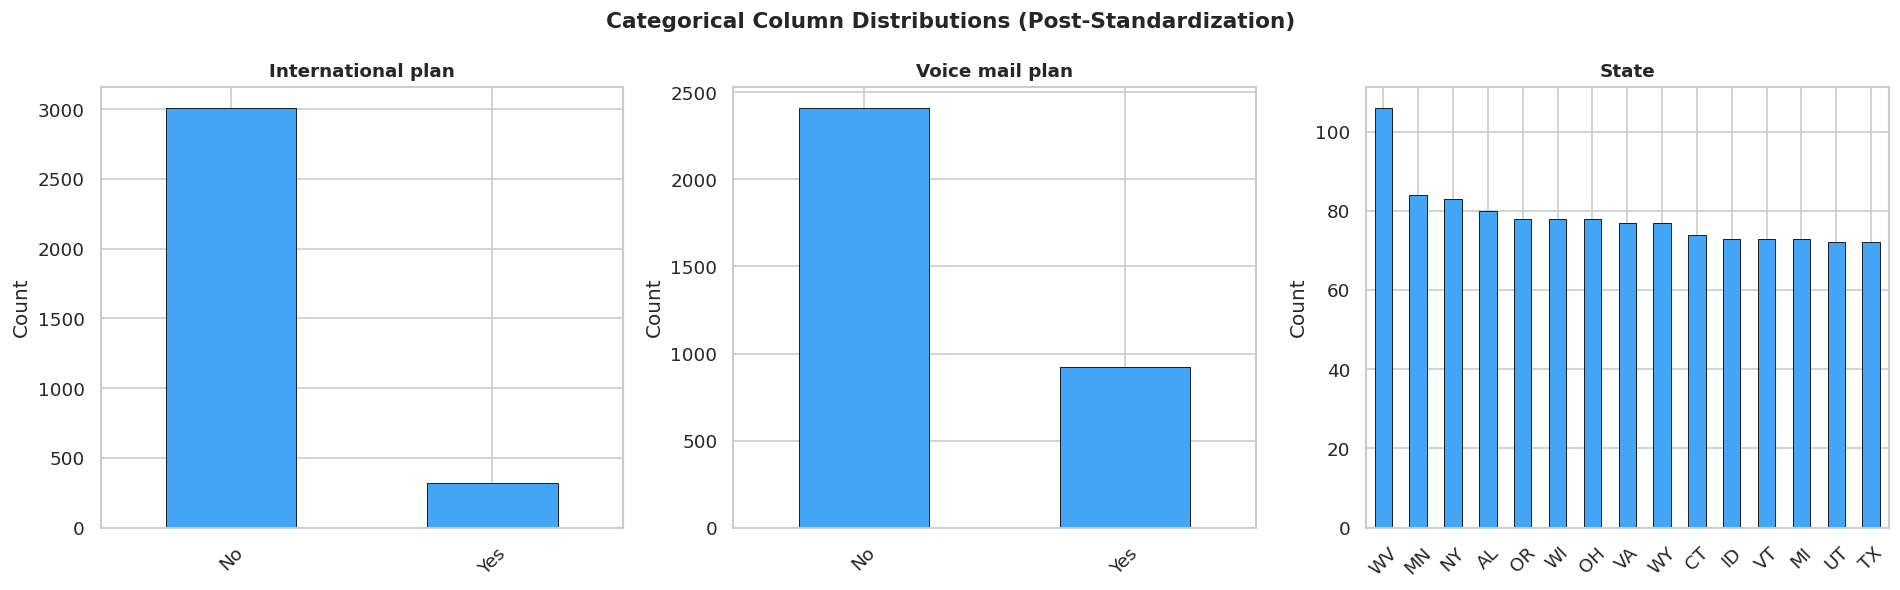

In [34]:
# Visualise categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['International plan', 'Voice mail plan', 'State']):
    vc = df[col].value_counts().head(15)  # top 15 for State
    vc.plot(kind='bar', ax=ax, color='#42A5F5', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Column Distributions (Post-Standardization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_categorical_distributions.png', bbox_inches='tight')
plt.show()


## Outlier Detection and Treatment

I use the **IQR (Interquartile Range) method** to flag and cap extreme values in numeric columns

In [35]:
# IQR-based outlier detection
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
# Exclude non-feature numerics
exclude = ['Area code']
num_cols = [c for c in num_cols if c not in exclude]

outlier_summary = []
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        outlier_summary.append({
            'Column'        : col,
            'Q1'            : round(Q1, 2),
            'Q3'            : round(Q3, 2),
            'IQR'           : round(IQR, 2),
            'Lower Fence'   : round(lower, 2),
            'Upper Fence'   : round(upper, 2),
            'Outlier Count' : n_out,
            'Outlier %'     : round(n_out / len(df) * 100, 2)
        })

out_df = pd.DataFrame(outlier_summary)
print(' Outlier Detection Report (IQR Method):')
print(out_df.to_string(index=False))

 Outlier Detection Report (IQR Method):
                Column     Q1     Q3   IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
        Account length  74.00 127.00 53.00        -5.50       206.50             18       0.54
 Number vmail messages   0.00  20.00 20.00       -30.00        50.00              1       0.03
     Total day minutes 143.70 216.40 72.70        34.65       325.45             25       0.75
       Total day calls  87.00 114.00 27.00        46.50       154.50             23       0.69
      Total day charge  24.43  36.79 12.36         5.89        55.33             25       0.75
     Total eve minutes 166.60 235.30 68.70        63.55       338.35             24       0.72
       Total eve calls  87.00 114.00 27.00        46.50       154.50             20       0.60
      Total eve charge  14.16  20.00  5.84         5.40        28.76             24       0.72
   Total night minutes 167.00 235.30 68.30        64.55       337.75             30       0.90
     Total

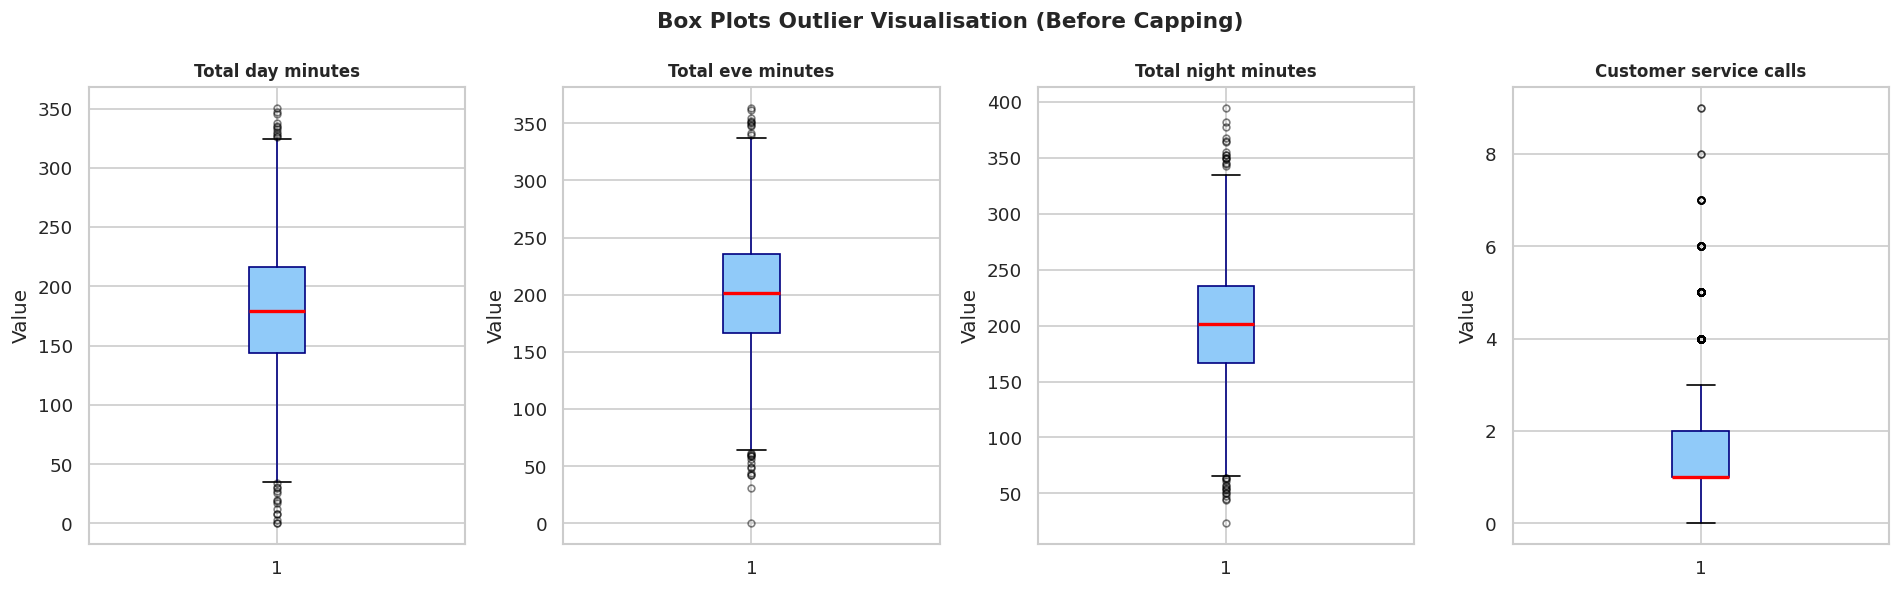

In [36]:
# Box plots before capping
key_cols = ['Total day minutes', 'Total eve minutes',
            'Total night minutes', 'Customer service calls']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots Outlier Visualisation (Before Capping)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_boxplots_before.png', bbox_inches='tight')
plt.show()

In [37]:
# Winsorisation (IQR capping)
print('Applying IQR Winsorisation (capping outliers)...')
print('-'*55)

for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_low  = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()

    if n_low > 0 or n_high > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  [{col}]  clipped {n_low} low + {n_high} high → [{lower:.2f}, {upper:.2f}]')

print('\n Winsorisation complete')

Applying IQR Winsorisation (capping outliers)...
-------------------------------------------------------
  [Account length]  clipped 0 low + 18 high → [-5.50, 206.50]
  [Number vmail messages]  clipped 0 low + 1 high → [-30.00, 50.00]
  [Total day minutes]  clipped 14 low + 11 high → [34.65, 325.45]
  [Total day calls]  clipped 15 low + 8 high → [46.50, 154.50]
  [Total day charge]  clipped 14 low + 11 high → [5.89, 55.33]
  [Total eve minutes]  clipped 14 low + 10 high → [63.55, 338.35]
  [Total eve calls]  clipped 11 low + 9 high → [46.50, 154.50]
  [Total eve charge]  clipped 14 low + 10 high → [5.40, 28.76]
  [Total night minutes]  clipped 15 low + 15 high → [64.55, 337.75]
  [Total night calls]  clipped 7 low + 15 high → [48.00, 152.00]
  [Total night charge]  clipped 15 low + 15 high → [2.91, 15.20]
  [Total intl minutes]  clipped 32 low + 14 high → [3.10, 17.50]
  [Total intl calls]  clipped 0 low + 78 high → [-1.50, 10.50]
  [Total intl charge]  clipped 32 low + 17 high → [0.84

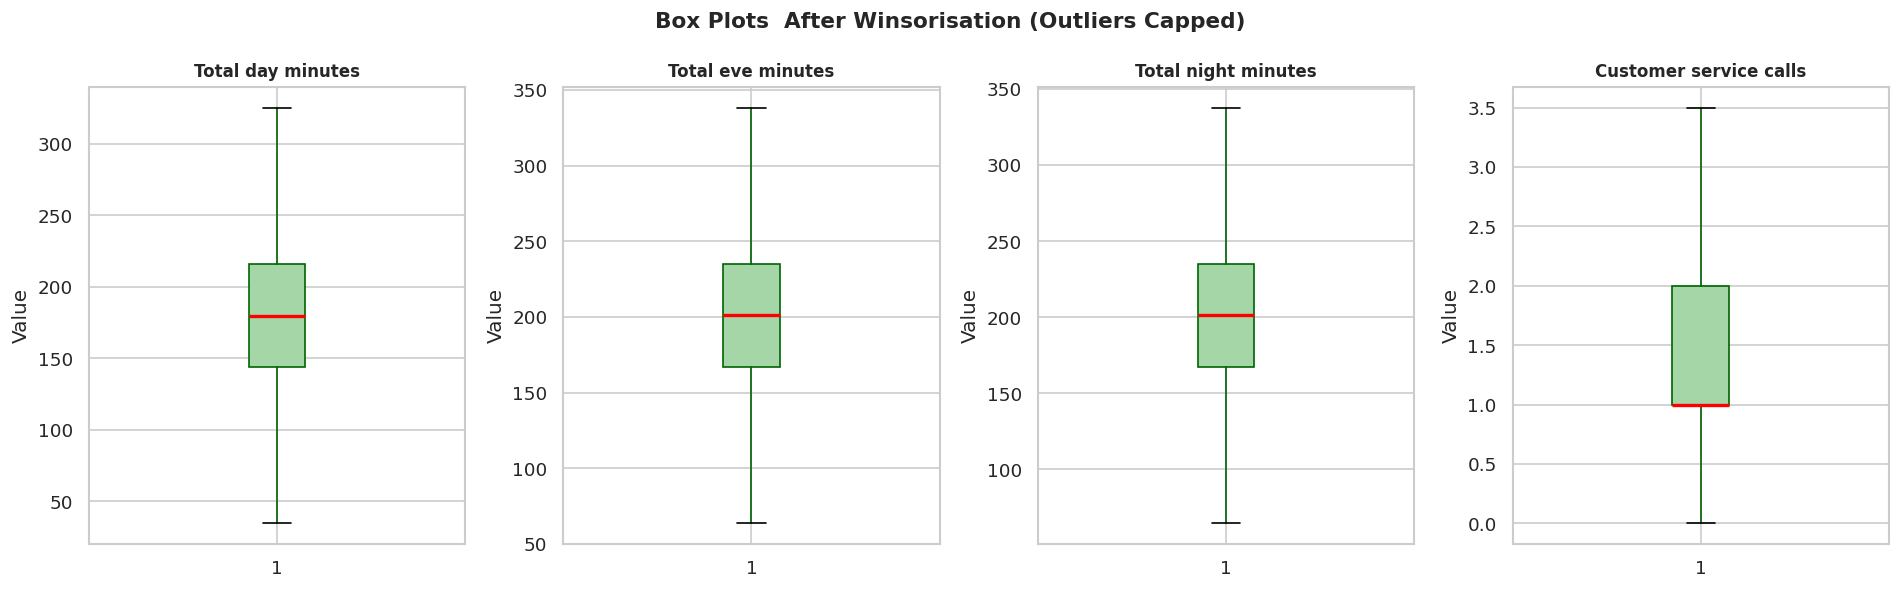

In [38]:
# Box plots after capping
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#A5D6A7', color='darkgreen'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='darkgreen'),
               flierprops=dict(marker='o', color='orange', markersize=4, alpha=0.5))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots  After Winsorisation (Outliers Capped)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_boxplots_after.png', bbox_inches='tight')
plt.show()

---
## Data Type Validation

Ensuring every column has the **correct data type** is essential for downstream processing.

In [39]:
# Enforce correct data types
print(' Enforcing data types ')

# Churn → boolean
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'True': True, 'False': False, True: True, False: False})

# Area code → category (it's a nominal code, not a number)
df['Area code']  = df['Area code'].astype('category')

# Binary Yes/No → category
df['International plan'] = df['International plan'].astype('category')
df['Voice mail plan']    = df['Voice mail plan'].astype('category')
df['State']              = df['State'].astype('category')

# Integer columns
int_cols = ['Account length','Number vmail messages',
            'Total day calls','Total eve calls',
            'Total night calls','Total intl calls','Customer service calls']
for col in int_cols:
    df[col] = df[col].astype(int)

print('\n Final Data Types:')
print(df.dtypes.to_string())

 Enforcing data types 

 Final Data Types:
State                     category
Account length               int64
Area code                 category
International plan        category
Voice mail plan           category
Number vmail messages        int64
Total day minutes          float64
Total day calls              int64
Total day charge           float64
Total eve minutes          float64
Total eve calls              int64
Total eve charge           float64
Total night minutes        float64
Total night calls            int64
Total night charge         float64
Total intl minutes         float64
Total intl calls             int64
Total intl charge          float64
Customer service calls       int64
Churn                         bool
_split                      object


In [40]:
#  Memory usage comparison
mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memory usage after optimisation: {mem_after:.2f} MB')
print(f'\nColumn dtypes summary:')
print(df.dtypes.value_counts().to_string())

Memory usage after optimisation: 0.57 MB

Column dtypes summary:
float64     8
int64       7
category    2
category    1
category    1
bool        1
object      1


In [41]:
#  Final overview
print('Clean dataset first 5 rows:')
df.drop(columns=['_split'], errors='ignore').head()

Clean dataset first 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.40,71,50.90,63.55,88,5.40,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [42]:
#  Verify zero missing values
assert df.isnull().sum().sum() == 0, ' Still has missing values!'
# Verify zero duplicates
assert df.duplicated().sum() == 0,   ' Still has duplicates!'

print(' All checks passed dataset is clean')
print(f'   Shape: {df.shape}')
print(f'   Churn rate: {df["Churn"].mean()*100:.1f}%')

 All checks passed dataset is clean
   Shape: (3333, 21)
   Churn rate: 14.5%


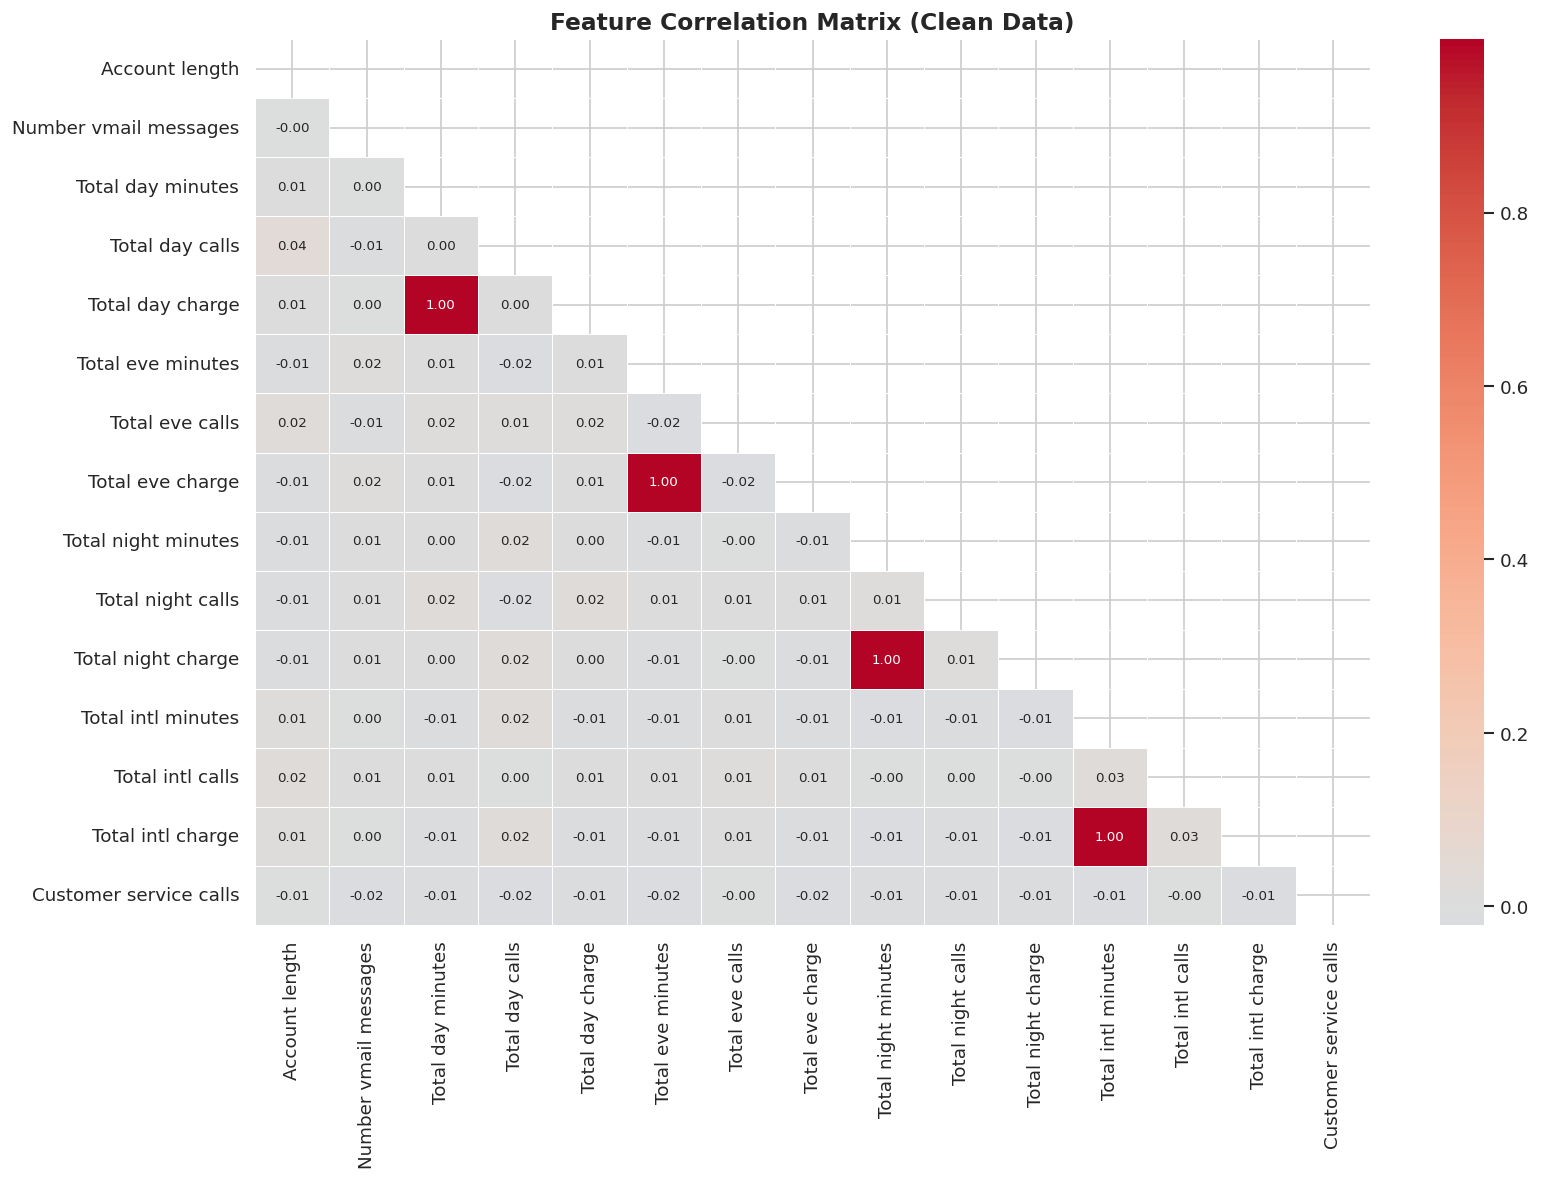

In [43]:
# Correlation heatmap of numeric features
num_df = df.select_dtypes(include=['float64','int64'])

fig, ax = plt.subplots(figsize=(14, 10))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (Clean Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
##  Save Cleaned Data


In [44]:
# Split back & drop helper column
df_train_clean = df[df['_split'] == 'train'].drop(columns=['_split']).reset_index(drop=True)
df_test_clean  = df[df['_split'] == 'test' ].drop(columns=['_split']).reset_index(drop=True)

# Save
df_train_clean.to_csv('churn_train_clean.csv', index=False)
df_test_clean.to_csv( 'churn_test_clean.csv',  index=False)

# Also save full clean dataset
df_full_clean = df.drop(columns=['_split'])
df_full_clean.to_csv('churn_full_clean.csv', index=False)

print(' Saved clean datasets:')
print(f'   churn_train_clean.csv → {df_train_clean.shape}')
print(f'   churn_test_clean.csv  → {df_test_clean.shape}')
print(f'   churn_full_clean.csv  → {df_full_clean.shape}')

 Saved clean datasets:
   churn_train_clean.csv → (2666, 20)
   churn_test_clean.csv  → (667, 20)
   churn_full_clean.csv  → (3333, 20)


In [45]:
#  Final preview of clean training data
print(' Clean Training Data : Statistical Summary:')
df_train_clean.describe().T.style.background_gradient(cmap='Greens', subset=['mean','std'])

 Clean Training Data : Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Account length,2666.000000,100.560390,39.388462,1.000000,73.000000,100.000000,127.000000,206.000000
Number vmail messages,2666.000000,8.021755,13.612277,0.000000,0.000000,0.000000,19.000000,50.000000
Total day minutes,2666.000000,179.536178,53.841588,34.650000,143.400000,179.950000,215.900000,325.450000
Total day calls,2666.000000,100.348462,19.794207,46.000000,87.000000,101.000000,114.000000,154.000000
Total day charge,2666.000000,30.521680,9.153054,5.890000,24.380000,30.590000,36.700000,55.330000
Total eve minutes,2666.000000,200.432821,50.639025,63.550000,165.300000,200.900000,235.100000,338.350000
Total eve calls,2666.000000,100.050638,19.997675,46.000000,87.000000,100.000000,114.000000,154.000000
Total eve charge,2666.000000,17.037033,4.304326,5.400000,14.050000,17.080000,19.980000,28.760000
Total night minutes,2666.000000,201.115979,50.320388,64.550000,166.925000,201.150000,236.475000,337.750000
Total night calls,2666.000000,100.102026,19.298896,48.000000,87.000000,100.000000,113.000000,152.000000
